# Autism Spectrum Disorder Screening Classification

## Project Objective

The objective of this project is to build a machine learning model that predicts whether a child exhibits Autism Spectrum Disorder (ASD) traits based on demographic and behavioral screening data using a Random Forest classifier implemented from scratch.

## Problem

Autism Spectrum Disorder (ASD) affects how individuals communicate, interact socially, and process the world around them. Early identification is critical. Research consistently shows that children who receive early intervention have significantly better developmental outcomes than those diagnosed later. However, formal clinical diagnosis is often slow, expensive, and inaccessible, especially in regions with limited access to specialists, leading to long waitlists and delayed support for families who need it most.

The AQ-10 (Autism Spectrum Quotient – 10 items) is a short, validated screening questionnaire designed to flag individuals who may benefit from a full diagnostic evaluation. It is not a diagnostic tool itself, it's a low-cost, accessible first step that helps prioritize who should seek professional assessment. The children's version used in this project is tailored for ages 4–11, capturing behavioral and attention patterns relevant to that age group.

This project investigates whether a screening outcome can be predicted using a combination of behavioral indicators and demographic / background information, with a particular focus on whether models can remain useful even when the most direct, leakage-prone source of signal (the AQ-10 total score) is excluded. The broader goal is to explore the potential and the limitations of using lightweight, data-driven screening tools to complement, not replace, clinical evaluation.

## Introduction to Dataset

We begin by loading the dataset and understanding its characteristics:

In [82]:
# Libraries

import pandas as pd
import numpy as np

import ucimlrepo

import matplotlib.pyplot as plt
import seaborn as sns

import random


## Dataset Loading

The dataset was obtained from the UCI Machine Learning Repository.

In [83]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=419)

X = dataset.data.features
Y = dataset.data.targets

data = pd.concat([X, Y], axis=1)

data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,class
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5,'4-11 years',Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,'Middle Eastern ',no,no,Jordan,no,5,'4-11 years',Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,NaN,no,no,Jordan,yes,5,'4-11 years',NaN,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,NaN,yes,no,Jordan,no,4,'4-11 years',NaN,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,'United States',no,10,'4-11 years',Parent,YES


In [84]:
# Display value counts for each column
for col in data.columns:
    counts = data[col].value_counts()
    print(f'data[{col}]')
    print(counts)
    print('\n')

data[A1_Score]
A1_Score
1    185
0    107
Name: count, dtype: int64


data[A2_Score]
A2_Score
1    156
0    136
Name: count, dtype: int64


data[A3_Score]
A3_Score
1    217
0     75
Name: count, dtype: int64


data[A4_Score]
A4_Score
1    161
0    131
Name: count, dtype: int64


data[A5_Score]
A5_Score
1    217
0     75
Name: count, dtype: int64


data[A6_Score]
A6_Score
1    208
0     84
Name: count, dtype: int64


data[A7_Score]
A7_Score
1    177
0    115
Name: count, dtype: int64


data[A8_Score]
A8_Score
0    147
1    145
Name: count, dtype: int64


data[A9_Score]
A9_Score
0    148
1    144
Name: count, dtype: int64


data[A10_Score]
A10_Score
1    212
0     80
Name: count, dtype: int64


data[age]
age
4.0     92
5.0     45
6.0     39
7.0     27
11.0    26
8.0     21
9.0     20
10.0    18
Name: count, dtype: int64


data[gender]
gender
m    208
f     84
Name: count, dtype: int64


data[ethnicity]
ethnicity
White-European       108
Asian                 46
'Middle Eastern '     27
'

From the result above, we can summarize the dataset description:

- `Age`: age in years
- `Gender`: Male or Female
- `Ethnicity`: The applicant's ethnicity
- `Jaundice`: Whether the case was born with jaundice (Y/N)
- `Autism`: Whether any immidiate family member has a PDD (Y/N)
- `Relation`: Who is completing the test (Parent, self, caregiver, medical staff, clinician ,etc.)
- `Country_Of_Res`: Country of residency
- `Used_App_Before`: Whether the user has used a screening app (Y/N)
- `Age_Desc`: Age category, which is 4-11 years old
- `A1_Score` to `A10_Score`: The answer code of the question based on the screening method used (1/0)
- `Result`: Total score of answer

In [85]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         292 non-null    int64  
 1   A2_Score         292 non-null    int64  
 2   A3_Score         292 non-null    int64  
 3   A4_Score         292 non-null    int64  
 4   A5_Score         292 non-null    int64  
 5   A6_Score         292 non-null    int64  
 6   A7_Score         292 non-null    int64  
 7   A8_Score         292 non-null    int64  
 8   A9_Score         292 non-null    int64  
 9   A10_Score        292 non-null    int64  
 10  age              288 non-null    float64
 11  gender           292 non-null    str    
 12  ethnicity        249 non-null    str    
 13  jaundice         292 non-null    str    
 14  autism           292 non-null    str    
 15  country_of_res   292 non-null    str    
 16  used_app_before  292 non-null    str    
 17  result           292 non-nu

In [86]:
data.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,288.000000,292.000000
mean,0.633562,0.534247,0.743151,0.551370,0.743151,0.712329,0.606164,0.496575,0.493151,0.726027,6.354167,6.239726
std,0.482658,0.499682,0.437646,0.498208,0.437646,0.453454,0.489438,0.500847,0.500811,0.446761,2.365456,2.284882
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,5.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,6.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.000000,10.000000


## Standardizing Data

### Standardizing Column Names

Column names were standardized by converting them to title case to improve readability and maintain consistency throughout the analysis.

In [87]:
data.columns = data.columns.str.title()

### Inspecting Categorical Variables

Categorical variables were examined to identify potential data entry inconsistencies, spelling variations, and unusual categories.

In [88]:
data.groupby('Gender')['Class'].count()
data.groupby('Ethnicity')['Class'].count()
data.groupby('Country_Of_Res')['Class'].count()
data.groupby('Used_App_Before')['Class'].count()
data.groupby('Relation')['Class'].count()
data.groupby('Class')['Gender'].count()

Class
NO     151
YES    141
Name: Gender, dtype: int64

### Standardizing Text Data

Text-based categorical variables were cleaned by removing leading and trailing spaces, removing quotation marks, and converting all values to lowercase. This ensured consistent category labels and prevented duplicate categories caused by formatting differences.

In [89]:
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = (data[col]
               .str.strip()
               .str.strip("'\"")   # remove leading/trailing quote characters
               .str.strip()        # remove whitespace that was hiding inside the quotes
               .str.lower())

C:\Users\Vika Permata Joe\AppData\Local\Temp\ipykernel_17624\3399900592.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns


## Handling Missing Values

Missing values were identified in Age, Ethnicity, and Relation. Records with missing Age values were removed due to their small proportion (less than 5%). Missing values in Ethnicity and Relation were assigned an "unknown" category to preserve observations while avoiding demographic assumptions.

In [90]:
data.isnull().sum() * 100 / len(data)

A1_Score            0.000000
A2_Score            0.000000
A3_Score            0.000000
A4_Score            0.000000
A5_Score            0.000000
A6_Score            0.000000
A7_Score            0.000000
A8_Score            0.000000
A9_Score            0.000000
A10_Score           0.000000
Age                 1.369863
Gender              0.000000
Ethnicity          14.726027
Jaundice            0.000000
Autism              0.000000
Country_Of_Res      0.000000
Used_App_Before     0.000000
Result              0.000000
Age_Desc            0.000000
Relation           14.726027
Class               0.000000
dtype: float64

In [91]:
data.dropna(subset=['Age'], inplace=True)

data['Ethnicity'] = data['Ethnicity'].fillna('Unknown')
data['Relation'] = data['Relation'].fillna('Unknown')

In [92]:
# verify:
data.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
Age                0
Gender             0
Ethnicity          0
Jaundice           0
Autism             0
Country_Of_Res     0
Used_App_Before    0
Result             0
Age_Desc           0
Relation           0
Class              0
dtype: int64

## Exploratory Data Analysis

We examined the dataset through visual analysis using seaborn to plot distributions, correlations, and demographic breakdowns that inform our preprocessing and modeling decisions.

### Class Histogram

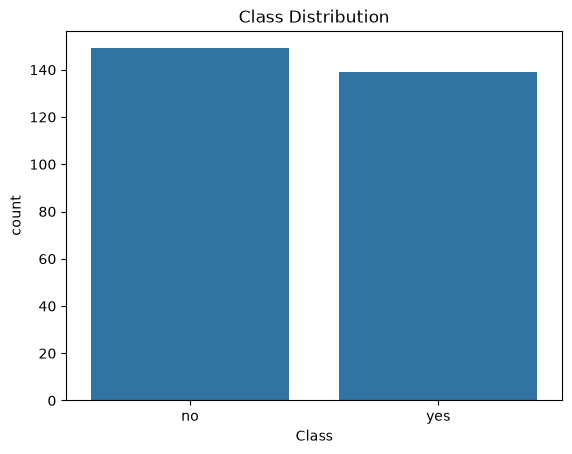

In [93]:
sns.countplot(x='Class', data=data)

plt.title('Class Distribution')
plt.show()

The class distribution is relatively balanced across the two screening outcomes. Out of 292 children, 148 were screened negative for ASD (No), while 139 screened positive (Yes) (a near-even 52:48 split). This is a favorable characteristic for a classification task, as it means the model is unlikely to be biased toward predicting the majority class, and standard accuracy remains a reasonably meaningful metric alongside recall and F1-score.

### Age Histogram

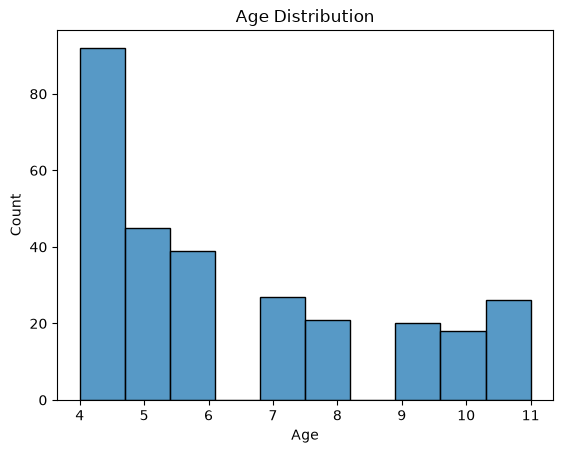

In [94]:
sns.histplot(data['Age'])

plt.title('Age Distribution')
plt.show()

The age distribution across the dataset spans from 4 to 11 years, consistent with the children's screening scope. The distribution is notably right-skewed, with younger children making up the bulk of the data, where age 4 accounts for the largest group at 92 instances, followed by ages 5 and 6 with 45 and 39 instances respectively. Representation drops off from age 7 onward, with each remaining age group sitting between 18 and 26 instances. This imbalance is worth noting: the model will have seen considerably more examples from younger age groups during training, which may affect how reliably it generalizes to screening outcomes for older children in the 9–11 range.

### Countplot of Gender

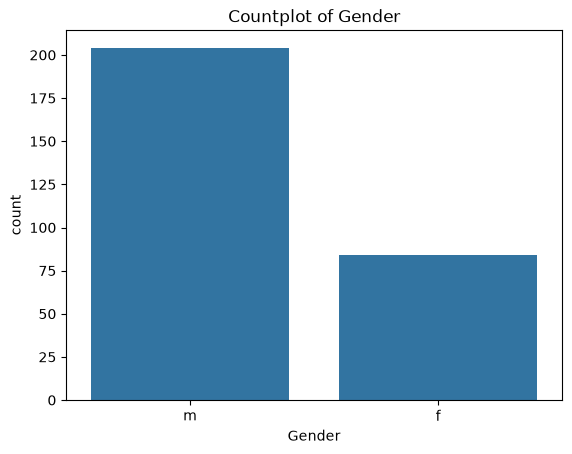

In [95]:
sns.countplot(x='Gender', data=data)

plt.title('Countplot of Gender')
plt.show()

The gender distribution shows a notable skew toward male children, with 204 instances compared to 83 female (a roughly 71:29 split). This imbalance is not incidental; it actually reflects a well-established epidemiological pattern in ASD research, where males are consistently diagnosed at significantly higher rates than females, often cited at a ratio of around 4:1. While this makes the gender imbalance in the dataset expected and clinically grounded, it is still worth flagging as a modeling consideration (the model will have seen far more male cases during training, which may affect its sensitivity when screening female children). This is especially relevant given ongoing research suggesting that ASD in females is frequently underdiagnosed due to differing behavioral presentations, meaning the dataset's label itself may carry this real-world bias forward.

### Countplot of Ethnicity

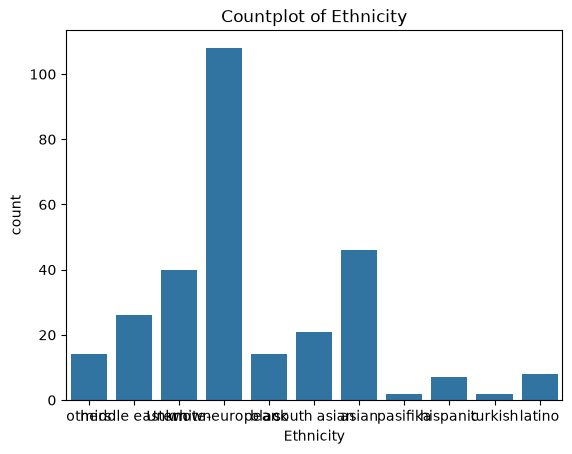

In [96]:
sns.countplot(x='Ethnicity', data=data)

plt.title('Countplot of Ethnicity')
plt.show()

The ethnicity distribution highlights a significant imbalance across groups in the dataset. White-European is the dominant group by a wide margin, with 108 instances, followed by Asian at 46 and Hispanic at 40. The remaining groups (Middle Eastern (26), South Asian (21), Latino (9), Turkish (7), Pasifika (3), Black (visible but small), and Other (15)) are considerably underrepresented. This degree of imbalance is a meaningful limitation: with some ethnicities represented by fewer than 10 instances, the model has very little basis to learn reliable patterns for those groups. This also raises a fairness concern worth acknowledging in the limitations section where a model trained on this distribution may not generalize equally well across all ethnic backgrounds, which is a particularly sensitive consideration in a healthcare screening context.

### Countplot of Jaundice

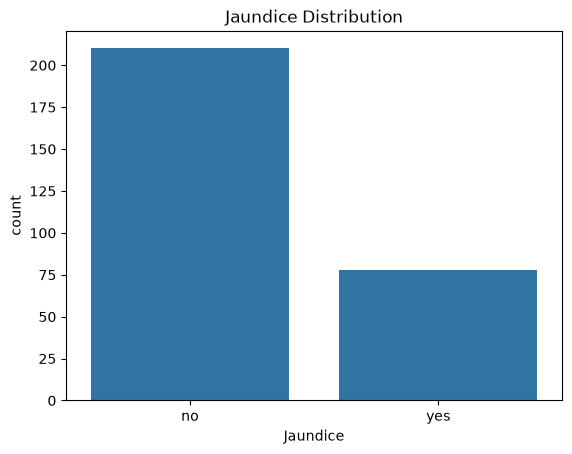

In [97]:
sns.countplot(x='Jaundice', data=data)

plt.title('Jaundice Distribution')
plt.show()

The jaundice distribution reveals that the majority of children in the dataset were not born with jaundice, accounting for 209 instances compared to 78 who were. This roughly 73:27 split indicates that jaundice history is a minority characteristic in this sample. It is worth noting that neonatal jaundice has been explored in existing literature as a potential early biological risk factor associated with ASD, making this a feature of genuine clinical interest despite its imbalance, and one to pay attention to when examining feature importances later in the modeling section.

### Countplot of Family Member with PDD

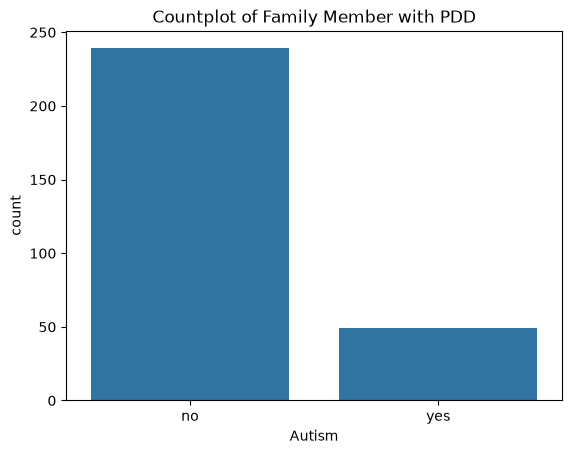

In [98]:
sns.countplot(x='Autism', data=data)

plt.title('Countplot of Family Member with PDD')
plt.show()

The distribution of family history of Pervasive Developmental Disorder (PDD) shows that the majority of children (240 instances) have no family member with PDD, while 50 do. This 83:17 split makes family history a relatively rare characteristic in the dataset. Despite its low frequency, it remains a clinically meaningful feature: ASD is known to have a strong hereditary component, with siblings and first-degree relatives of diagnosed individuals carrying a significantly elevated likelihood of also being on the spectrum. As such, even with limited representation, this feature may carry disproportionate predictive signal relative to its count, making it one to watch closely when interpreting feature importances in the modeling section.

### Countplot of Whether The User Has Used App

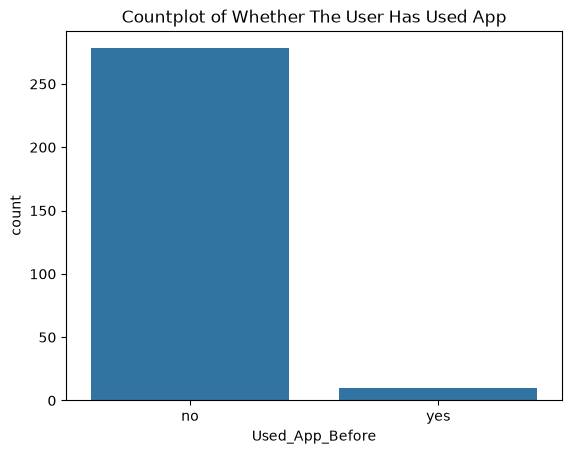

In [99]:
sns.countplot(x='Used_App_Before', data=data)

plt.title('Countplot of Whether The User Has Used App')
plt.show()

The vast majority of respondents (approximately 279 instances) had not previously used an ASD screening app, with only around 10 having done so. This extreme 97:3 imbalance makes used_app_before an effectively near-constant feature in this dataset. As flagged during the preprocessing stage, a feature with this little variation carries almost no discriminative power for the model regardless of any real-world relationship it might have with screening outcomes. This column is a strong candidate for exclusion before modeling — or at minimum, worth noting explicitly in the limitations section as a feature that simply cannot be evaluated meaningfully at this sample size.

## Label Encoding

### Converting to Numerical Values

In [100]:
# Using get_dummies for 2 categorical values
gender = pd.get_dummies(data['Gender'], prefix = 'Gender', dtype=int, drop_first=True)
jaundice = pd.get_dummies(data['Jaundice'], prefix = 'Jaundice', dtype=int, drop_first=True)
autism = pd.get_dummies(data['Autism'], prefix = 'Autism', dtype=int, drop_first=True)
class_lbl = pd.get_dummies(data['Class'], prefix = 'Class', dtype=int, drop_first=True)

In [101]:
# Using mapping for more than two categorical values
for col in ['Ethnicity', 'Country_Of_Res', 'Relation']:
    categories = data[col].unique()
    mapping = {cat: i for i, cat in enumerate(categories)}
    data[col] = data[col].map(mapping)
    print(f"{col}: {mapping}")  # we keep this to know what number maps to what

Ethnicity: {'others': 0, 'middle eastern': 1, 'Unknown': 2, 'white-european': 3, 'black': 4, 'south asian': 5, 'asian': 6, 'pasifika': 7, 'hispanic': 8, 'turkish': 9, 'latino': 10}
Country_Of_Res: {'jordan': 0, 'united states': 1, 'egypt': 2, 'united kingdom': 3, 'bahrain': 4, 'austria': 5, 'kuwait': 6, 'united arab emirates': 7, 'europe': 8, 'malta': 9, 'bulgaria': 10, 'south africa': 11, 'india': 12, 'afghanistan': 13, 'georgia': 14, 'new zealand': 15, 'syria': 16, 'iraq': 17, 'australia': 18, 'saudi arabia': 19, 'armenia': 20, 'turkey': 21, 'pakistan': 22, 'canada': 23, 'oman': 24, 'brazil': 25, 'south korea': 26, 'costa rica': 27, 'sweden': 28, 'philippines': 29, 'malaysia': 30, 'argentina': 31, 'japan': 32, 'bangladesh': 33, 'qatar': 34, 'ireland': 35, 'romania': 36, 'netherlands': 37, 'lebanon': 38, 'germany': 39, 'latvia': 40, 'russia': 41, 'italy': 42, 'china': 43, 'nigeria': 44, 'u.s. outlying islands': 45, 'nepal': 46, 'mexico': 47, 'isle of man': 48, 'libya': 49, 'ghana': 50

In [102]:
data = pd.concat([data, gender, jaundice, autism, class_lbl], axis=1)

In [103]:
data.drop(['Gender', 'Jaundice', 'Autism', 'Class', 'Age_Desc', 'Used_App_Before'], axis=1, inplace=True)

In [104]:
data.info()

<class 'pandas.DataFrame'>
Index: 288 entries, 0 to 291
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   A1_Score        288 non-null    int64  
 1   A2_Score        288 non-null    int64  
 2   A3_Score        288 non-null    int64  
 3   A4_Score        288 non-null    int64  
 4   A5_Score        288 non-null    int64  
 5   A6_Score        288 non-null    int64  
 6   A7_Score        288 non-null    int64  
 7   A8_Score        288 non-null    int64  
 8   A9_Score        288 non-null    int64  
 9   A10_Score       288 non-null    int64  
 10  Age             288 non-null    float64
 11  Ethnicity       288 non-null    int64  
 12  Country_Of_Res  288 non-null    int64  
 13  Result          288 non-null    int64  
 14  Relation        288 non-null    int64  
 15  Gender_m        288 non-null    int64  
 16  Jaundice_yes    288 non-null    int64  
 17  Autism_yes      288 non-null    int64  
 18  Class_

### HeatMap

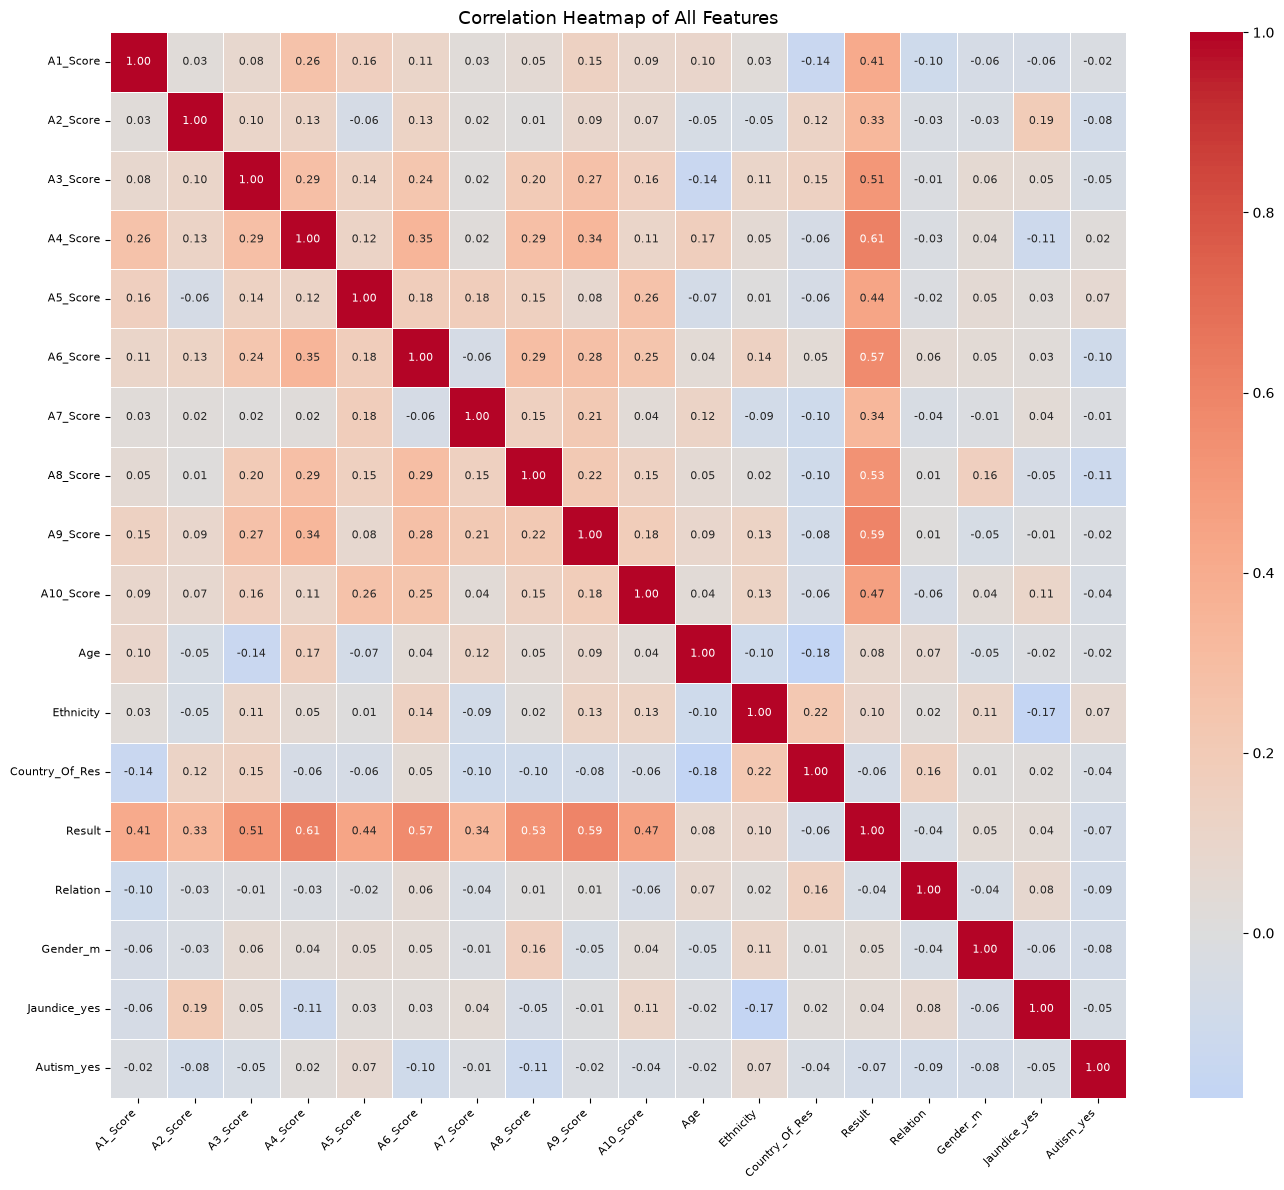

In [105]:
# Heatmap

x = data.drop(columns=['Class_yes'])

plt.figure(figsize=(14, 12))
sns.heatmap(x.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation Heatmap of All Features', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Based on the correlation heatmap above, `Result` have high correlation with `A1_Score` to `A10_Score`. This is expected since result is the total score of answer. Therefore, we dropped this variable to avoid multicollinearity.

In [106]:
data.drop(['Result'], axis=1, inplace=True)

In [107]:
# Save our final dataset

data.to_csv('final_dataset.csv', index=False)

In [108]:
df = pd.read_csv('final_dataset.csv', header = None)

df = df.sample(frac = 1)
data_list = df.values.tolist()

## Building a Machine Learning Model

### Why We Use a Random Forest Model?

We chose Random Forest because it naturally handles both numerical and categorical features, and its ensemble structure (averaging predictions across many decorrelated decision trees) substantially reduces the overfitting that a single decision tree is prone to. Implementing it from scratch also made it possible to directly control and inspect the bootstrap sampling and feature randomization steps that drive this variance reduction, rather than treating them as a black box.

### Data Splitting

In [109]:
# Train-Test Split

training_data = data_list[0:231]
testing_data = data_list[231:289]

## Random Forest Implementation

Rather than using a pre-built Random Forest implementation, a custom Random Forest classifier was developed using Python, NumPy, and Pandas.

The implementation consists of:

1. Bootstrap sampling for generating training subsets.
2. Decision tree construction using recursive node splitting.
3. Gini impurity calculation for split evaluation.
4. Random feature selection at each split.
5. Majority voting across trees for final classification.

### Helper Functions

In [110]:
# Helper function to store set of values in each column

def unique_vals(rows, col): #it will iterate over all the rows using for loop, and in each iteration, it would be one row, and it will return its column as a list and this list will be converted into set
    return set([row[col] for row in rows]) #set stores unique values

In [111]:
# Helper function to get dict with keys 0 or 1 for survived/not and values is the total

def class_counts(rows): #it will return the numb of classes in these rows
    counts = {}
    for row in rows:
        label = row[-1]
        if label not in counts:
            counts[label] = 0
        counts[label] += 1
    return counts

In [112]:
# Helper function to check if the value is numeric or not

def is_num(value):
    return isinstance(value, int) or isinstance(value, float)

In [113]:
# Helper function how to ask question in the root

class Question:
    def __init__(self, col, val):
        self.column = col
        self.value = val
    def match(self, example):
        val = example[self.column]
        if is_num(val):
            return val >= self.value
        else:
            return val == self.value

### Dataset Splitting Function

In [114]:
# Helper function to split the data between true and false

def partition(rows, question):
    true_rows, false_rows = [], []
    for row in rows:
        if question.match(row):
            true_rows.append(row)
        else:
            false_rows.append(row)
    return true_rows, false_rows

### Gini Impurity Function

In [115]:
def gini(rows):
    counts = class_counts(rows)
    impurity = 1
    for lbl in counts:
        prob_of_lbl = counts[lbl] / float(len(rows))
        impurity -= prob_of_lbl ** 2
    return impurity

### Information Gain Function

In [116]:
def information_gain(left, right, current_impurity): #right row
    prob = float(len(left)) / (len(left) + len(right))
    return current_impurity - prob * gini(left) - (1 - prob) * gini(right)

### Best Split Selection

In [117]:
def best_split(rows):
    best_gain = 0
    best_question = None
    current_impurity = gini(rows)
    n_features = len(rows[0])-1

    for col in range(n_features):
        values = set([row[col] for row in rows])
        for val in values:
            question = Question(col, val)
            true_rows, false_rows = partition(rows, question)

            if len(true_rows) == 0 or len(false_rows) == 0:
                continue

            gain = information_gain(true_rows, false_rows, current_impurity)

            if gain >= best_gain:
                best_gain, best_question = gain, question
    return best_gain, best_question

### Tree Node Creation

In [118]:
# Function for Leaf node

class Leaf:
    def __init__(self, rows):
        self.predictions = class_counts(rows)

In [119]:
# Function for Decision node

class DecisionNode:
    def __init__(self, question, true_branch, false_branch):
        self.question = question 
        self.true_branch = true_branch
        self.false_branch = false_branch

### Tree Building

In [120]:
def build_tree(rows):
    gain, question = best_split(rows)

    if gain == 0:
        return Leaf(rows)

    true_rows, false_rows = partition(rows, question)
    true_branch = build_tree(true_rows)
    false_branch = build_tree(false_rows)

    return DecisionNode(question, true_branch, false_branch)

### Classifier Function

In [121]:
# Function to classify if it is a leaf or decision tree

def classify(row, node):
    if isinstance(node, Leaf):
        return node.predictions

    if node.question.match(row):
        return classify(row, node.true_branch)

    else:
        return classify(row, node.false_branch)

### Bootstrap Sampling

In [122]:
def bootstrap_sample(rows):
    sample = []
    for _ in range(len(rows)):
        # randomly pick a row WITH replacement
        random_row = rows[random.randint(0, len(rows) - 1)]
        sample.append(random_row)
    return sample

### Random Forest Construction

In [123]:
def build_forest(rows, n_trees=10):
    forest = []
    for i in range(n_trees):
        # Step 1 — get random sample of rows
        sample = bootstrap_sample(rows)
        
        # Step 2 — build a tree on that sample
        tree = build_tree(sample)
        
        # Step 3 — add tree to forest
        forest.append(tree)
        print(f"Tree {i+1} built ✅")
    
    return forest

### Prediction via Majority Voting

In [215]:
def forest_classify(row, forest):
    # collect prediction from each tree
    votes = {}
    for tree in forest:
        prediction = list(classify(row, tree).keys())[0]
        
        # count votes for each class
        if prediction not in votes:
            votes[prediction] = 0
        votes[prediction] += 1
    
    # return the class with most votes
    return max(votes, key=votes.get)

## Build Our Random Forest

In [216]:
# Build the forest
random.seed(100000)
forest = build_forest(training_data, n_trees=43)

Tree 1 built ✅
Tree 2 built ✅
Tree 3 built ✅
Tree 4 built ✅
Tree 5 built ✅
Tree 6 built ✅
Tree 7 built ✅
Tree 8 built ✅
Tree 9 built ✅
Tree 10 built ✅
Tree 11 built ✅
Tree 12 built ✅
Tree 13 built ✅
Tree 14 built ✅
Tree 15 built ✅
Tree 16 built ✅
Tree 17 built ✅
Tree 18 built ✅
Tree 19 built ✅
Tree 20 built ✅
Tree 21 built ✅
Tree 22 built ✅
Tree 23 built ✅
Tree 24 built ✅
Tree 25 built ✅
Tree 26 built ✅
Tree 27 built ✅
Tree 28 built ✅
Tree 29 built ✅
Tree 30 built ✅
Tree 31 built ✅
Tree 32 built ✅
Tree 33 built ✅
Tree 34 built ✅
Tree 35 built ✅
Tree 36 built ✅
Tree 37 built ✅
Tree 38 built ✅
Tree 39 built ✅
Tree 40 built ✅
Tree 41 built ✅
Tree 42 built ✅
Tree 43 built ✅


## Model Evaluation

### Accuracy, Precision, Recall, F1 Score

In [217]:
# Testing loop

TP = 0
TN = 0
FP = 0
FN = 0

for row in testing_data:
    prediction = forest_classify(row[0:-1], forest)
    actual = row[-1]

    if prediction == '1' and actual == '1':
        TP += 1

    elif prediction == '0' and actual == '0':
        TN += 1

    elif prediction == '1' and actual == '0':
        FP += 1

    elif prediction == '0' and actual == '1':
        FN += 1

In [218]:
# Calculate model evaluation

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8448
Precision: 0.8846
Recall   : 0.7931
F1 Score : 0.8364


**Interpretation:**

The model correctly classified approximately 84.5% of children in the test set, well above the ~51% baseline a majority-class guess would achieve given the dataset's near-even class split.

**An important caveat on these results:** while the `Result` column (the precomputed AQ-10 total) was excluded to avoid the most direct form of label leakage, the ten individual A1–A10 item scores were retained as features. Since `Class/ASD` is defined as a threshold on the *sum* of these exact ten items, the model still has indirect access to nearly all the information used to construct the label itself — it must learn the additive relationship across binary splits rather than reading it off a single precomputed column, but the underlying signal is the same. This likely explains why performance lands at 84.5% rather than the ~100% achievable with `Result` included directly: the tree-based splits recover most, but not all, of that additive pattern.

As a result, these metrics should be read as evidence that the model *can substantially reconstruct the AQ-10 screening rule from raw item-level responses* — a meaningful technical result in its own right — rather than as evidence that ASD screening status can be predicted from independent behavioral or demographic signal alone. A more rigorous test of the latter question would require excluding A1–A10 entirely and relying only on demographic and background features, which we explore as a follow-up experiment below.

Looking at the individual metrics: precision (0.8846) exceeds recall (0.7931), meaning the model is more reliable when it predicts a positive screen than when it's tasked with catching every true positive case — it misses roughly 1 in 5 children who should screen positive. In a real screening context, this kind of false negative is generally costlier than a false positive, since it represents a missed opportunity for early referral. This gap would be the priority area to address before considering any real-world application of a model like this.


### Confusion Matrix

In [220]:
print("\nConfusion Matrix")
print(f"TN = {TN}    FP = {FP}")
print(f"FN = {FN}    TP = {TP}")

cm = np.array([
    [TN, FP],
    [FN, TP]
])

print(cm)


Confusion Matrix
TN = 26    FP = 3
FN = 6    TP = 23
[[26  3]
 [ 6 23]]


**Interpretation:**

Out of 58 children in the test set:

- **26 true negatives**: correctly identified as not screening positive for ASD.
- **23 true positives**: correctly flagged as screening positive.
- **3 false positives**: children incorrectly flagged as a positive screen when they were not. In a screening context, this is the cheaper error: it leads to an unnecessary follow-up evaluation, but no missed opportunity for support.
- **6 false negatives**: children who should have screened positive but were missed by the model. This is the more consequential error type in a screening application, since it represents a child who may not get referred for early intervention they could benefit from.

The model produces roughly twice as many false negatives as false positives (6 vs. 3), which aligns with the precision-recall gap observed earlier (precision 0.8846 > recall 0.7931). This consistently points to the same conclusion: the model is conservative about predicting a positive screen, erring on the side of "no" when uncertain — the opposite of what's ideal for a screening tool, where catching borderline cases matters more than avoiding false alarms.

This reinforces that, were this model considered for any real-world screening use, the priority improvement would be reducing false negatives, even if that means accepting a higher false positive rate, rather than optimizing for overall accuracy.